In [185]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install geopandas
# !pip install geoalchemy2
# !pip install sqlalchemy

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
import os
import glob

In [186]:
# !pip install psycopg2
# !pip install psycopg2-binary --user
# !pip install psycopg[binary]

from sqlalchemy import create_engine
import psycopg2
import psycopg2.extras
import json

credentials = "/Users/apple/Desktop/Data2901/Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

In [187]:
db, conn = pgconnect(credentials)

Connected successfully.


In [188]:
query(conn, "select PostGIS_Version()")

,postgis_version
0,3.4 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


# 1. import all the data

In [189]:
# get all the files in csv
path = os.getcwd() 
csv_files = glob.glob(os.path.join(path, "*/*.csv")) 

print(csv_files)

# create empty list
dataframes_list = []
 
# append datasets into the list
for i in csv_files:
    temp_df = pd.read_csv(i)
    dataframes_list.append(temp_df)

df_income = dataframes_list[0]
df_pop = dataframes_list[1]
df_pol = dataframes_list[2]
df_business = dataframes_list[3]
print("Income: ",df_income.shape,'; ',df_income.columns)
print('Population: ',df_pop.shape,'; ',df_pop.columns)
print('Polling: ',df_pol.shape,'; ',df_pol.columns)
print('Business: ',df_business.shape,'; ',df_business.columns)

['/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Income.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Population.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/PollingPlaces2019.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Businesses.csv']
Income:  (642, 6) ;  Index(['sa2_code21', 'sa2_name', 'earners', 'median_age', 'median_income',
       'mean_income'],
      dtype='object')
Population:  (373, 21) ;  Index(['sa2_code', 'sa2_name', '0-4_people', '5-9_people', '10-14_people',
       '15-19_people', '20-24_people', '25-29_people', '30-34_people',
       '35-39_people', '40-44_people', '45-49_people', '50-54_people',
       '55-59_people', '60-64_people', '65-69_people', '70-74_people',
       '75-79_people', '80-84_people', '85-and-over_people', 'total_people'],
      dtype='object')
Polling:  (2930, 17) ;  Index(['FID', 'state', 'division_id', 'division_name', 'polling_place_id',
       'polling_pl

In [190]:
df_income.head()

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640,68904
1,101021008,Karabar,5103,42,65564,69672
2,101021009,Queanbeyan,7028,39,63528,69174
3,101021010,Queanbeyan - East,3398,39,66148,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630,91981


In [191]:
df_pop.head()

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,572,602,570,520,464,369,226,142,70,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,749,794,895,863,925,603,331,264,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,325,436,422,397,327,264,190,100,75,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,859,882,901,930,917,1065,976,773,1028,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1330,1241,1377,1285,1166,949,664,476,537,21346


In [235]:
df_pol.tail()

,FID,state,division_id,division_name,polling_place_id,polling_place_type_id,polling_place_name,premises_name,premises_address_1,premises_address_2,premises_address_3,premises_suburb,premises_state_abbreviation,premises_post_code,latitude,longitude,the_geom
2925,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,2809,1,Warilla South,Warilla High School,10 Keross Ave,NaN,NaN,BARRACK HEIGHTS,NSW,2528.0,-34.564200,150.858000,POINT (-34.5642 150.858)
2926,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,58798,5,Warilla WHITLAM PPVC,2/144 Shellharbour Rd,NaN,NaN,NaN,WARILLA,NSW,2528.0,-34.550823,150.859755,POINT (-34.5508228 150.8597546)
2927,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,31242,1,Welby,Welby Community Hall,14 Currockbilly St,NaN,NaN,WELBY,NSW,2575.0,-34.440900,150.424000,POINT (-34.4409 150.424)
2928,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,564,1,Windang,Windang Public School,60-64 Oakland Ave,NaN,NaN,WINDANG,NSW,2528.0,-34.531600,150.866000,POINT (-34.5316 150.866)
2929,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,58667,5,Wollongong WHITLAM PPVC,3/51 Crown St,NaN,NaN,NaN,WOLLONGONG,NSW,2500.0,NaN,NaN,NaN


In [193]:
df_business.head()

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16


## import txt files

In [263]:
# import txt file
# path = os.getcwd() 
txt_files = glob.glob(os.path.join(path, "*/*.txt")) 
print(txt_files[0])
i = txt_files[0]
df_stops = pd.read_csv(i)
print(df_stops.shape)
print(df_stops.columns)
df_stops.tail()

/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Stops.txt
(114718, 9)
Index(['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon',
       'location_type', 'parent_station', 'wheelchair_boarding',
       'platform_code'],
      dtype='object')


,stop_id,stop_code,stop_name,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code
114713,212753,212753.0,"Sydney Olympic Park Wharf, Side B",-33.822016,151.078797,NaN,21271,1,B
114714,2137185,2137185.0,"Cabarita Wharf, Side A",-33.840669,151.116926,NaN,21371,1,1A
114715,2137186,2137186.0,"Cabarita Wharf, Side B",-33.840769,151.116899,NaN,21371,1,1B
114716,21501,21501.0,Parramatta Wharf,-33.813904,151.010577,NaN,2150112,1,NaN
114717,2150112,NaN,Parramatta Wharf,-33.813952,151.010482,1.0,NaN,1,NaN


## read the shp file from catchments

In [195]:
# get the shp files
print(path)
shp_files = glob.glob(os.path.join(path, "*/*/*.shp")) 

# create empty list
dataframes_list_shp = []
 
# append datasets into the list
for i in shp_files:
    print(i)
    temp_df = gpd.read_file(i)
    dataframes_list_shp.append(temp_df)

df_catch_f = dataframes_list_shp[0]
df_catch_s = dataframes_list_shp[1]
df_catch_p = dataframes_list_shp[2]
df_sa2 = dataframes_list_shp[3]
print("catchment future: ",df_catch_f.shape,'; ',df_catch_f.columns)
print('catchment secondary: ',df_catch_s.shape,'; ',df_catch_s.columns)
print('catchment primary: ',df_catch_p.shape,'; ',df_catch_p.columns)
print('sa2: ',df_sa2.shape,'; ',df_sa2.columns)

df_catch_f.head()

/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/catchments/catchments_secondary.shp


/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/catchments/catchments_future.shp
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/catchments/catchments_primary.shp
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp
catchment future:  (436, 19) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry'],
      dtype='object')
catchment secondary:  (30, 18) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'geometry'],
      dtype='object')
catchment primary:  (1662, 19) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', '

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.67182 -35.31444, 146.68930 -35.3..."
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((147.08734 -35.86271, 147.10413 -35.8..."
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.81448 -35.78341, 146.81250 -35.7..."
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"MULTIPOLYGON (((150.68600 -33.74031, 150.68631..."
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((150.69513 -33.75627, 150.68936 -33.7..."


In [196]:
df_sa2.head()

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.21800 -35.3..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.19970 -35.3..."


In [197]:
df_catch_s['PRIORITY'] = 'None'
df_catch_s1 = df_catch_s[['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry']]

In [198]:
df_school = pd.concat([df_catch_f, df_catch_s1,df_catch_p])
print(df_school.shape)
df_school.tail()

(2128, 19)


,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((147.94621 -34.55863, 147.95292 -34.5..."
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((148.12885 -35.60082, 148.23155 -35.6..."
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((146.86148 -35.87511, 146.87402 -35.8..."
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((145.18403 -29.65805, 145.18434 -29.6..."
1661,2155,PRIMARY,Hermidale PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((146.46001 -31.31688, 146.47453 -31.3..."


In [199]:
#transform to multipolygon
srid = 4326

def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

df_schoolog = df_school.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
df_school['geom'] = df_school['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_school = df_school.drop(columns="geometry")  # deleting the old copy
df_school

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geom
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((146.67182402032344 -35.3144375...
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((147.08733806259178 -35.8627146...
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((146.81447829547324 -35.7834062...
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((150.68599834118749 -33.7403060...
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((150.69513440644116 -33.7562688...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((147.9462089946497 -34.55863148...
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((148.12885348977485 -35.6008184...
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((146.86147943204122 -35.8751106...
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((145.18402754685187 -29.6580498...


In [200]:
# df_sa2['geometry'].geom_type == 'Polygon'
df_sa2.dtypes

SA2_CODE21      object
SA2_NAME21      object
CHG_FLAG21      object
CHG_LBL21       object
SA3_CODE21      object
SA3_NAME21      object
SA4_CODE21      object
SA4_NAME21      object
GCC_CODE21      object
GCC_NAME21      object
STE_CODE21      object
STE_NAME21      object
AUS_CODE21      object
AUS_NAME21      object
AREASQKM21     float64
LOCI_URI21      object
geometry      geometry
dtype: object

In [201]:
df_sa2og = df_sa2.copy()  # creating a copy of the original for laterog = df_sa2.copy()  # creating a copy of the original for later
df_sa2 = df_sa2[df_sa2.geometry.type == 'Polygon']
df_sa2['geom'] = df_sa2['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_sa2 = df_sa2.drop(columns="geometry")  # deleting the old copy
df_sa2['SA2_CODE21'] = df_sa2['SA2_CODE21'].astype(int)
df_sa2 

/Applications/anaconda3/lib/python3.8/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geom
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.58423846300806 -35.4442571...
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.2189874391411 -35.36738117...
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.21326493309647 -35.3432452...
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.2403376383506 -35.34780977...
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.19572324350193 -35.3612624...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2460,801101145,Molonglo - East,1,New,80110,Molonglo,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,7.3323,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.05296755302768 -35.3015961...
2461,801101146,Whitlam,1,New,80110,Molonglo,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,3.2590,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.05113657739636 -35.2692051...
2462,801111140,ACT - South West,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,416.7824,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((148.8838115837419 -35.26411249...
2463,801111141,Namadgi,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,1202.7527,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((148.8040699920124 -35.37619101...


# 2. data validations

In [202]:
## check data types, nulls, duplicates, unique values
df_school.dtypes

USE_ID        object
CATCH_TYPE    object
USE_DESC      object
ADD_DATE      object
KINDERGART    object
YEAR1         object
YEAR2         object
YEAR3         object
YEAR4         object
YEAR5         object
YEAR6         object
YEAR7         object
YEAR8         object
YEAR9         object
YEAR10        object
YEAR11        object
YEAR12        object
PRIORITY      object
geom          object
dtype: object

In [203]:
print(df_school.shape)
print(df_school.drop_duplicates().shape)

print(df_business.shape)
print(df_business.drop_duplicates().shape)

print(df_income.shape)
print(df_income.drop_duplicates().shape)

print(df_pol.shape)
print(df_pol.drop_duplicates().shape)

print(df_pop.shape)
print(df_pop.drop_duplicates().shape)
# no duplicated rows

(2128, 19)
(2128, 19)
(12217, 11)
(12217, 11)
(642, 6)
(642, 6)
(2930, 17)
(2930, 17)
(373, 21)
(373, 21)


In [204]:
print(df_school.isna().sum())
df_school.nunique()

USE_ID           0
CATCH_TYPE       0
USE_DESC         0
ADD_DATE       391
KINDERGART       0
YEAR1            0
YEAR2            0
YEAR3            0
YEAR4            0
YEAR5            0
YEAR6            0
YEAR7            0
YEAR8            0
YEAR9            0
YEAR10           0
YEAR11           0
YEAR12           0
PRIORITY      2087
geom             0
dtype: int64


USE_ID        2035
CATCH_TYPE       7
USE_DESC      2035
ADD_DATE       209
KINDERGART       4
YEAR1            4
YEAR2            4
YEAR3            4
YEAR4            4
YEAR5            4
YEAR6            4
YEAR7            4
YEAR8            4
YEAR9            4
YEAR10           5
YEAR11           5
YEAR12           6
PRIORITY         3
geom          2084
dtype: int64

In [205]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [206]:
print(df_pol.dtypes)
print(df_pol.isna().sum())
df_pol.nunique()

FID                             object
state                           object
division_id                      int64
division_name                   object
polling_place_id                 int64
polling_place_type_id            int64
polling_place_name              object
premises_name                   object
premises_address_1              object
premises_address_2              object
premises_address_3              object
premises_suburb                 object
premises_state_abbreviation     object
premises_post_code             float64
latitude                       float64
longitude                      float64
the_geom                        object
dtype: object
FID                               0
state                             0
division_id                       0
division_name                     0
polling_place_id                  0
polling_place_type_id             0
polling_place_name                0
premises_name                     0
premises_address_1              193

FID                            2930
state                             1
division_id                      47
division_name                    47
polling_place_id               2930
polling_place_type_id             4
polling_place_name             2757
premises_name                  2463
premises_address_1             2408
premises_address_2               46
premises_address_3                7
premises_suburb                1522
premises_state_abbreviation       3
premises_post_code              593
latitude                       2498
longitude                      2242
the_geom                       2543
dtype: int64

In [207]:
print(df_pop.isna().sum())
df_pop.nunique()

sa2_code              0
sa2_name              0
0-4_people            0
5-9_people            0
10-14_people          0
15-19_people          0
20-24_people          0
25-29_people          0
30-34_people          0
35-39_people          0
40-44_people          0
45-49_people          0
50-54_people          0
55-59_people          0
60-64_people          0
65-69_people          0
70-74_people          0
75-79_people          0
80-84_people          0
85-and-over_people    0
total_people          0
dtype: int64


sa2_code              373
sa2_name              373
0-4_people            324
5-9_people            327
10-14_people          332
15-19_people          318
20-24_people          324
25-29_people          340
30-34_people          336
35-39_people          331
40-44_people          328
45-49_people          326
50-54_people          326
55-59_people          317
60-64_people          314
65-69_people          304
70-74_people          302
75-79_people          286
80-84_people          258
85-and-over_people    272
total_people          365
dtype: int64

In [208]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [209]:
print(df_income.dtypes)
print(df_income.isna().sum())
df_income.nunique()

sa2_code21        int64
sa2_name         object
earners          object
median_age       object
median_income    object
mean_income      object
dtype: object
sa2_code21       0
sa2_name         0
earners          0
median_age       0
median_income    0
mean_income      0
dtype: int64


sa2_code21       642
sa2_name         642
earners          623
median_age        29
median_income    635
mean_income      631
dtype: int64

# 3. import into sql 

In [264]:
conn.execute("""
DROP TABLE IF EXISTS polls;
CREATE TABLE polls (
    FID                             varchar(100),
state                           varchar(100),
division_id                      integer,
division_name                   varchar(100),
polling_place_id                 integer,
polling_place_type_id            integer,
polling_place_name              varchar(100),
premises_name                   varchar(100),
premises_address_1              varchar(100),
premises_address_2              varchar(100),
premises_address_3              varchar(100),
premises_suburb                 varchar(100),
premises_state_abbreviation     varchar(100),
premises_post_code             integer,
latitude                       float,
longitude                      float,
the_geom                       GEOMETRY(POINT,4326)
);"""
)
df_pol.to_sql('polls', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from polls")

conn.execute("""
DROP TABLE IF EXISTS populations;
CREATE TABLE populations (
    pop_est NUMERIC, 
    continent VARCHAR(80), 
    name VARCHAR(80), 
    iso_a3 VARCHAR(80), 
    gdp_md_est NUMERIC,
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)
df_pop.to_sql('populations', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from populations")

conn.execute("""
DROP TABLE IF EXISTS incomes;
CREATE TABLE incomes (
    sa2_code21        integer,
sa2_name         varchar(100),
earners          varchar(100),
median_age       varchar(100),
median_income    varchar(100),
mean_income      varchar(100)
);"""
)
df_income.to_sql('incomes', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from incomes")

conn.execute("""
DROP TABLE IF EXISTS schools;
CREATE TABLE schools (
USE_ID        integer,
CATCH_TYPE    varchar(100),
USE_DESC      varchar(100),
ADD_DATE      date,
KINDERGART    varchar(100),
YEAR1         varchar(100),
YEAR2         varchar(100),
YEAR3         varchar(100),
YEAR4         varchar(100),
YEAR5         varchar(100),
YEAR6         varchar(100),
YEAR7         varchar(100),
YEAR8         varchar(100),
YEAR9         varchar(100),
YEAR10        varchar(100),
YEAR11        varchar(100),
YEAR12        varchar(100),
PRIORITY      varchar(100),
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)
df_school.to_sql('schools', conn, if_exists='replace', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from schools")


conn.execute("""
DROP TABLE IF EXISTS business;
CREATE TABLE business (
    industry_code             varchar(100),
    industry_name             varchar(100),
    sa2_code                   integer,
    sa2_name                  varchar(100),
    "0_to_50k_businesses"       integer,
    "50k_to_200k_businesses"     integer,
    "200k_to_2m_businesses"      integer,
    "2m_to_5m_businesses"        integer,
    "5m_to_10m_businesses"       integer,
    "10m_or_more_businesses"     integer,
    total_businesses           integer
);"""
)
df_business.to_sql('business', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from business")


conn.execute("""
DROP TABLE IF EXISTS stops;
CREATE TABLE stops (
stop_id int, 
stop_code int, 
stop_name varchar(100), 
stop_lat float, 
stop_lon float,
location_type int, 
parent_station int, 
wheelchair_boarding int,
platform_code varchar(100)
);"""
)
df_stops.to_sql('stops', conn, if_exists='replace', index=False)
query(conn, "select * from stops")


conn.execute("""
DROP TABLE IF EXISTS sa2;
CREATE TABLE sa2 (
SA2_CODE21      integer,
SA2_NAME21      varchar(100),
CHG_FLAG21      varchar(100),
CHG_LBL21       varchar(100),
SA3_CODE21      integer,
SA3_NAME21      varchar(100),
SA4_CODE21      integer,
SA4_NAME21      varchar(100),
GCC_CODE21      varchar(100),
GCC_NAME21      varchar(100),
STE_CODE21      integer,
STE_NAME21      varchar(100),
AUS_CODE21      varchar(100),
AUS_NAME21      varchar(100),
AREASQKM21     float,
LOCI_URI21      varchar(100),
geometry      geometry(Multipolygon,4326)
             );"""
)
df_sa2.to_sql('sa2', conn, if_exists='replace', index=False, dtype={'geom': Geometry('Multipolygon', srid)})
query(conn, "select * from sa2")

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geom
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E6100000010000000103000000010000005D...
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E6100000010000000103000000010000002C...
2,101021610,Googong,1,New,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9164,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E6100000010000000103000000010000006D...
3,101021611,Queanbeyan Surrounds,1,New,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3047.7057,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E61000000100000001030000000200000041...
4,101031013,Bombala,0,No change,10103,Snowy Mountains,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3990.1440,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E61000000100000001030000000100000031...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,801101145,Molonglo - East,1,New,80110,Molonglo,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,7.3323,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E61000000100000001030000000100000071...
2239,801101146,Whitlam,1,New,80110,Molonglo,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,3.2590,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E61000000100000001030000000100000031...
2240,801111140,ACT - South West,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,416.7824,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E6100000010000000103000000010000000C...
2241,801111141,Namadgi,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,1202.7527,http://linked.data.gov.au/dataset/asgsed3/SA2/...,0106000020E6100000010000000103000000010000004B...


In [243]:
conn.execute(
	'''
	drop table combined;
    create table combined as
	with polls as (select *,ST_SetSRID(st_makepoint("longitude","latitude"),4326) as geom from polls
			   where the_geom is not null )
select 
s."SA2_CODE21",s."SA2_NAME21",s."SA3_NAME21",s."SA4_NAME21","STE_NAME21"
,i.earners
,i.median_age
,i.median_income
,i.mean_income
,sum(b."0_to_50k_businesses") as "0_to_50k_businesses"
,sum(b."50k_to_200k_businesses") as "50k_to_200k_businesses"
,sum(b."200k_to_2m_businesses") as "200k_to_2m_businesses"
,sum(b."2m_to_5m_businesses") as "2m_to_5m_businesses"
,sum(b."5m_to_10m_businesses") as "5m_to_10m_businesses"
,sum(b."10m_or_more_businesses") as "10m_or_more_businesses"
,sum(b.total_businesses) as total_businesses
,sum(ppl."0-4_people") as "0-4_people"
,sum(ppl."5-9_people") as "5-9_people"
,sum(ppl."10-14_people") as "10-14_people"
,sum(ppl."15-19_people") as "15-19_people"
,sum(ppl."20-24_people") as "20-24_people"
,sum(ppl."25-29_people") as "25-29_people"
,sum(ppl."30-34_people") as "30-34_people"
,sum(ppl."35-39_people") as "35-39_people"
,sum(ppl."40-44_people") as "40-44_people"
,sum(ppl."45-49_people") as "45-49_people"
,sum(ppl."50-54_people") as "50-54_people"
,sum(ppl."55-59_people") as "55-59_people"
,sum(ppl."60-64_people") as "60-64_people"
,sum(ppl."65-69_people") as "65-69_people"
,sum(ppl."70-74_people") as "70-74_people"
,sum(ppl."75-79_people") as "75-79_people"
,sum(ppl."80-84_people") as "80-84_people"
,sum(ppl."85-and-over_people") as "85-and-over_people"
,sum(ppl."total_people") as "total_people"
,count(distinct p.*) as num_polls

from sa2 s
left join business b on b.sa2_code = s."SA2_CODE21" -- inner 11229
left join populations ppl on ppl.sa2_code = s."SA2_CODE21"-- inner 359
left join incomes i on i."sa2_code21" = s."SA2_CODE21" --inner 591
left join polls p on st_contains(s.geom,p.geom) -- 2505

group by 1,2,3,4,5,6,7,8,9
''')
query(conn, "select * from combined")

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,earners,median_age,median_income,mean_income,0_to_50k_businesses,...,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people,num_polls
0,101021007,Braidwood,Queanbeyan,Capital Region,New South Wales,2467,51,46640,68904,783.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
1,101021008,Karabar,Queanbeyan,Capital Region,New South Wales,5103,42,65564,69672,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,101021009,Queanbeyan,Queanbeyan,Capital Region,New South Wales,7028,39,63528,69174,1659.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
3,101021010,Queanbeyan - East,Queanbeyan,Capital Region,New South Wales,3398,39,66148,74162,175.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,101021012,Queanbeyan West - Jerrabomberra,Queanbeyan,Capital Region,New South Wales,8422,44,78630,91981,208.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,801101145,Molonglo - East,Molonglo,Australian Capital Territory,Australian Capital Territory,None,None,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2239,801101146,Whitlam,Molonglo,Australian Capital Territory,Australian Capital Territory,None,None,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2240,801111140,ACT - South West,Uriarra - Namadgi,Australian Capital Territory,Australian Capital Territory,None,None,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2241,801111141,Namadgi,Uriarra - Namadgi,Australian Capital Territory,Australian Capital Territory,None,None,None,None,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [211]:
df_sa2.dtypes

SA2_CODE21      int64
SA2_NAME21     object
CHG_FLAG21     object
CHG_LBL21      object
SA3_CODE21     object
SA3_NAME21     object
SA4_CODE21     object
SA4_NAME21     object
GCC_CODE21     object
GCC_NAME21     object
STE_CODE21     object
STE_NAME21     object
AUS_CODE21     object
AUS_NAME21     object
AREASQKM21    float64
LOCI_URI21     object
geom           object
dtype: object

In [212]:
df_business

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...
12212,S,Other Services,128021538,Sutherland - Kirrawee,21,66,58,3,3,0,152
12213,S,Other Services,128021607,Engadine,13,41,31,3,0,0,87
12214,S,Other Services,128021608,Loftus - Yarrawarrah,0,10,10,0,0,0,22
12215,S,Other Services,128021609,Woronora Heights,0,3,5,0,0,0,9


## Merge into 1 big dataset based on SA2Codes (except schools)

In [ ]:
query(conn, '''
      select * 
      from sa2 s
      left join ''')

# plot

In [229]:
query(conn, "select * from schools")

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geom
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020E6100000010000000103000000010000006D...
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020E61000000100000001030000000100000071...
2,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020E6100000010000000103000000020000002F...
3,8502,HIGH_COED,Tomaree HS,20211115,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020E6100000010000000103000000010000003B...
4,4581,PRIMARY,Frank Partridge VC PS,None,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020E61000000100000001030000000100000038...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2123,2409,PRIMARY,Lismore SPS,20200616,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020E610000001000000010300000001000000C9...
2124,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020E610000001000000010300000001000000B9...
2125,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020E610000001000000010300000001000000C0...
2126,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020E610000001000000010300000001000000F6...


<AxesSubplot:>

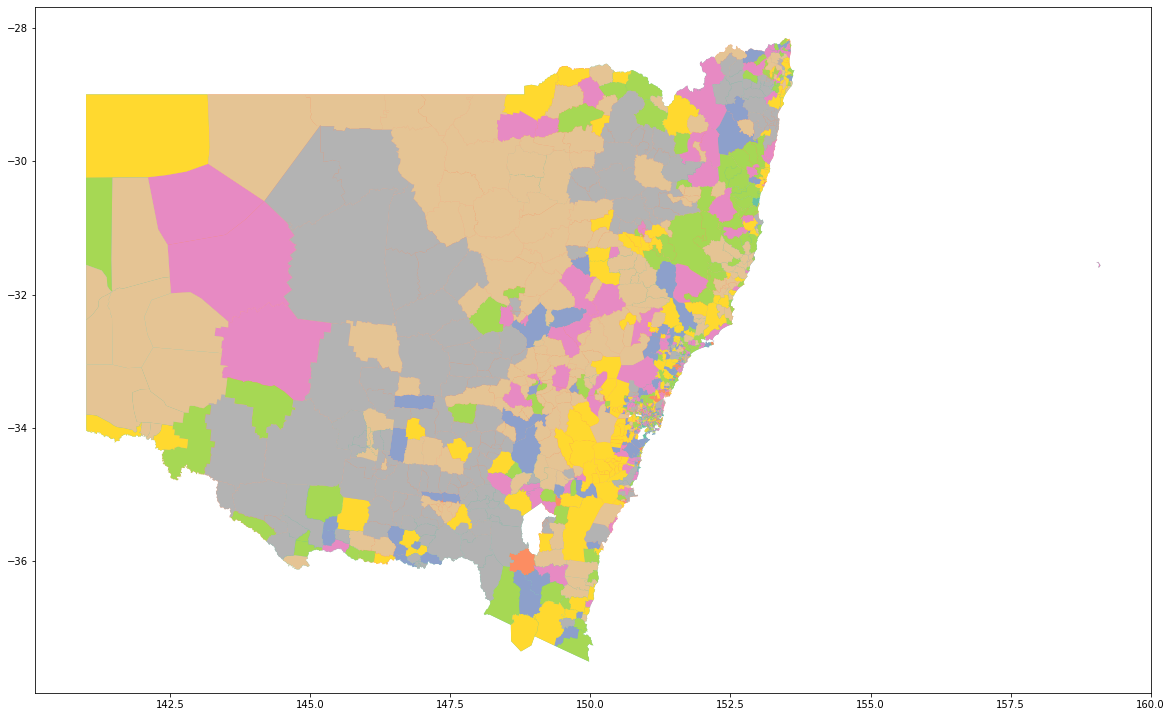

In [226]:
#school
schools = gpd.read_postgis('''select "USE_DESC",geom from schools''', conn, crs=4326)
schools.plot(figsize=(20, 20),cmap='Set2')

In [230]:
def calc_color(data, color=None):
        if color   == 1: 
            color_sq =  ['#dadaebFF','#bcbddcF0','#9e9ac8F0','#807dbaF0','#6a51a3F0','#54278fF0']; 
            colors = 'Purples';
        elif color == 2: 
            color_sq = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494']; 
            colors = 'YlGnBu';
        elif color == 3: 
            color_sq = ['#f7f7f7','#d9d9d9','#bdbdbd','#969696','#636363','#252525']; 
            colors = 'Greys';
        elif color == 9: 
            color_sq = ['#ff0000','#ff0000','#ff0000','#ff0000','#ff0000','#ff0000'];
                        
        else:           
            color_sq = ['#ffffd4','#fee391','#fec44f','#fe9929','#d95f0e','#993404']; 
            colors = 'YlOrBr';
        new_data, bins = pd.qcut(data, 6, retbins=True, 
        labels=list(range(6)))
        color_ton = []
        for val in new_data:
            color_ton.append(color_sq[val]) 
        if color != 9:
            colors = sns.color_palette(colors, n_colors=6)
            sns.palplot(colors, 0.6);
            for i in range(6):
                print ("\n"+str(i+1)+': '+str(int(bins[i]))+
                       " => "+str(int(bins[i+1])-1))
            print("\n\n   1   2   3   4   5   6")    
        return color_ton, bins

In [231]:
def plot_cities_data(sf, title, cities, data=None,color=None, print_id=False):
 
    color_ton, bins = calc_color(data, color)
    df = read_shapefile(sf)
    city_id = []
    for i in cities:
        city_id.append(df[df.DIST_NAME == 
                            i.upper()].index.get_values()[0])
    plot_map_fill_multiples_ids_tone(sf, title, city_id, 
                                     print_id, 
                                     color_ton, 
                                     bins, 
                                     x_lim = None, 
                                     y_lim = None, 
                                     figsize = (11,9));
def plot_map_fill_multiples_ids_tone(sf, title, city,  
                                     print_id, color_ton, 
                                     bins, 
                                     x_lim = None, 
                                     y_lim = None, 
                                     figsize = (11,9)):
   
        
    plt.figure(figsize = figsize)
    fig, ax = plt.subplots(figsize = figsize)
    fig.suptitle(title, fontsize=16)
    for shape in sf.shapeRecords():
        x = [i[0] for i in shape.shape.points[:]]
        y = [i[1] for i in shape.shape.points[:]]
        ax.plot(x, y, 'k')
            
    for id in city:
        shape_ex = sf.shape(id)
        x_lon = np.zeros((len(shape_ex.points),1))
        y_lat = np.zeros((len(shape_ex.points),1))
        for ip in range(len(shape_ex.points)):
            x_lon[ip] = shape_ex.points[ip][0]
            y_lat[ip] = shape_ex.points[ip][1]
        ax.fill(x_lon,y_lat, color_ton[city.index(id)])
        if print_id != False:
            x0 = np.mean(x_lon)
            y0 = np.mean(y_lat)
            plt.text(x0, y0, id, fontsize=10)
    if (x_lim != None) & (y_lim != None):     
        plt.xlim(x_lim)
        plt.ylim(y_lim)


In [233]:
names= ['jaipur','bikaner','churu','bhilwara','udaipur']
data = [100, 2000, 300, 400000, 500, 600, 100, 2000, 300, 400, 500, 600, 100, 2000, 300, 400, 500, 600]
print_id = True # The shape id will be printed
color_pallete = 1 # ‘Purple’
plot_cities_data(sf, 'Heat map of given cities', names, data, color_pallete, print_id)

<AxesSubplot:>

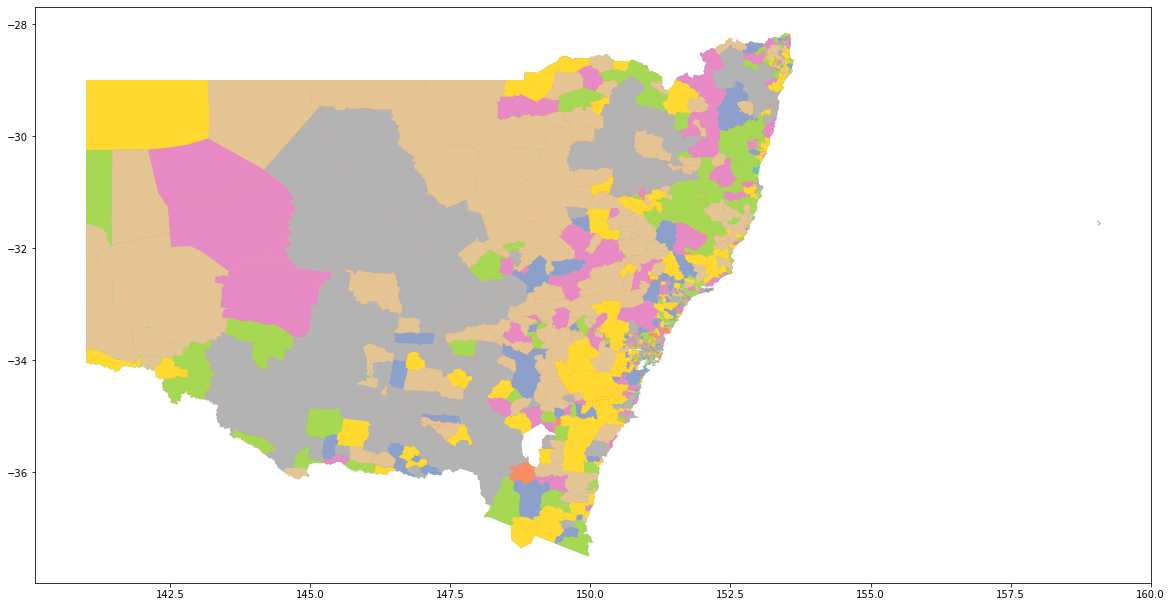

In [227]:
#school
schools = gpd.read_postgis('''select "USE_DESC",geom from schools''', conn, crs=7842)
schools.plot(figsize=(20, 20),cmap='Set2')

<AxesSubplot:>

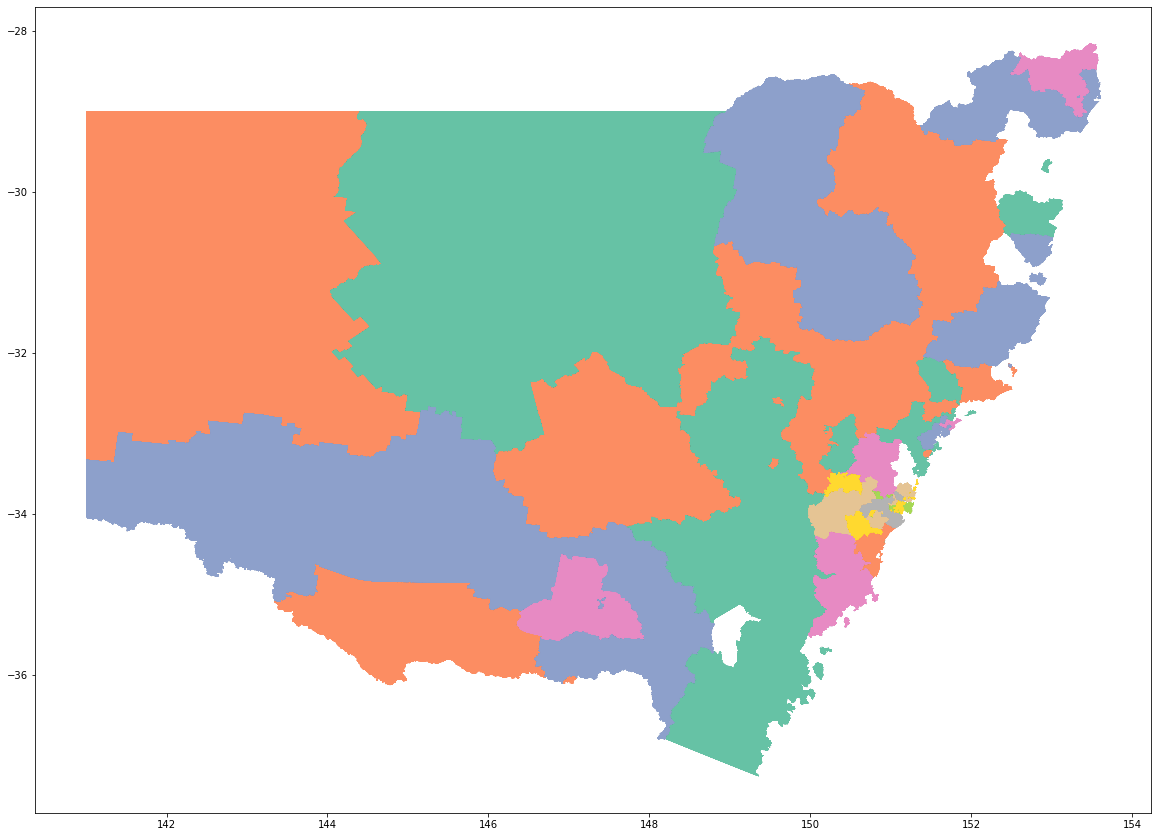

In [234]:
# business
#school
sa2 = gpd.read_postgis('''select "0_to_50k_businesses","50k_to_200k_businesses","200k_to_2m_businesses","2m_to_5m_businesses","5m_to_10m_businesses","10m_or_more_businesses",s.geom from business b join sa2 s on b.sa2_code = s."SA2_CODE21"''', conn, crs=7842)
sa2.plot(figsize=(20, 20),cmap='Set2')

<AxesSubplot:>

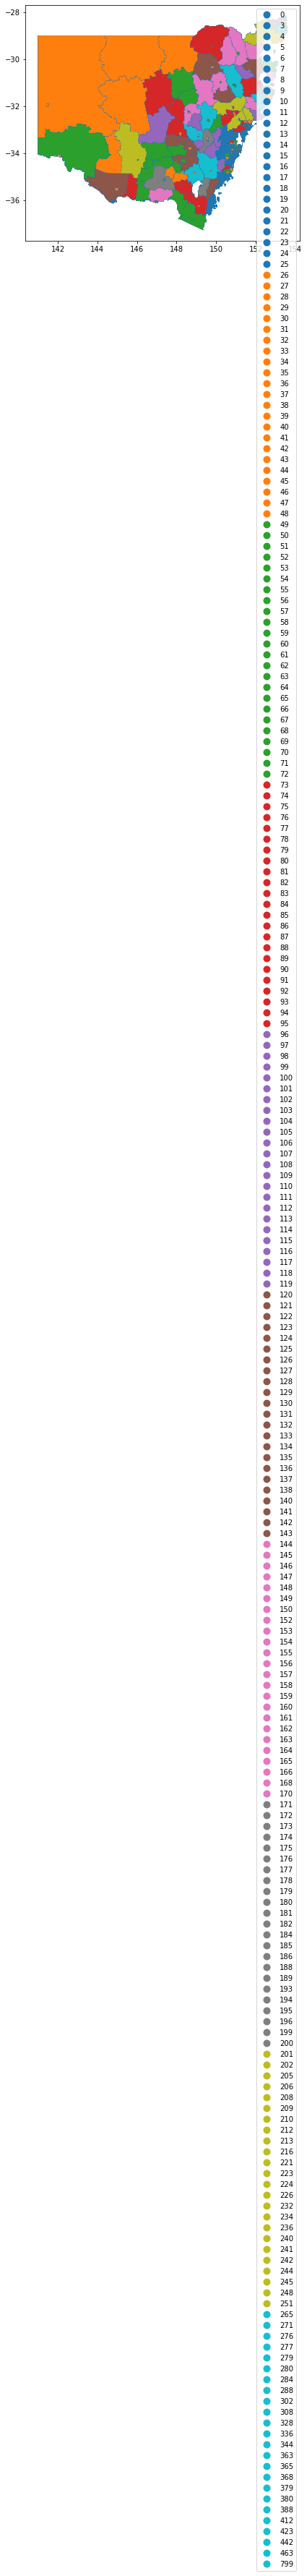

In [218]:
fig, ax = plt.subplots(figsize=(14, 6))
sa2.plot(column='0_to_50k_businesses',
                categorical=True,
                legend=True,
                ax=ax)


<AxesSubplot:>

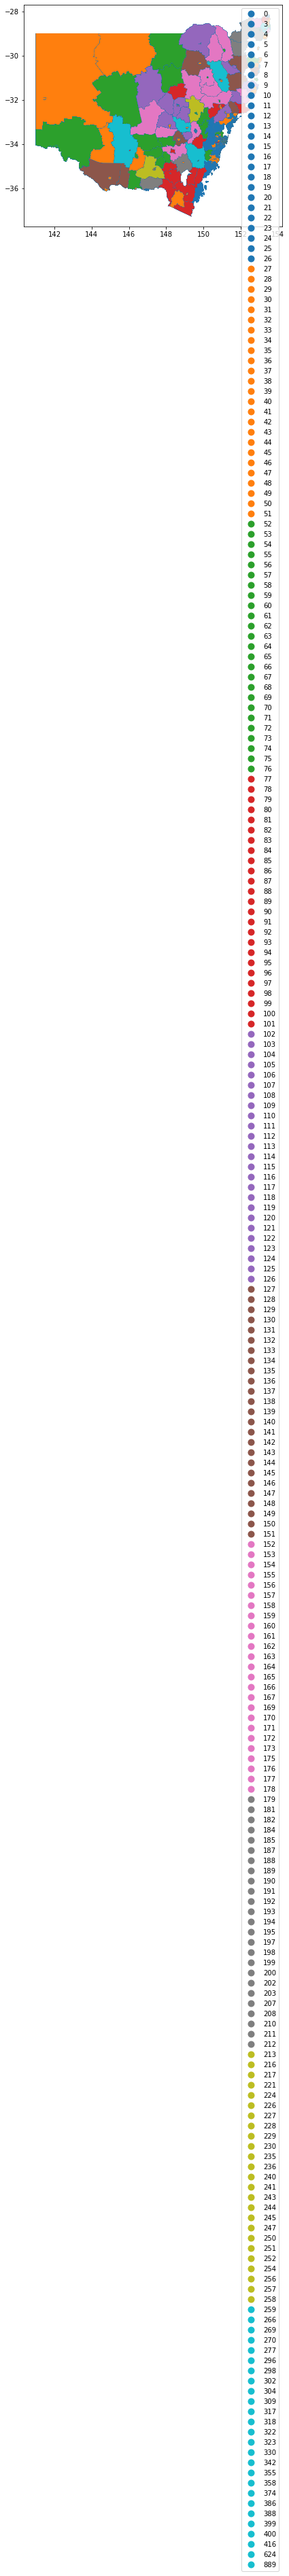

In [222]:
fig, ax = plt.subplots(figsize=(14, 6))
sa2.plot(column='50k_to_200k_businesses',
                categorical=True,
                legend=True,
                ax=ax)


# task 2

In [276]:
df = query(conn, "select * from combined where total_people is null or total_people = 'NaN'")
df.columns

Index(['SA2_CODE21', 'SA2_NAME21', 'SA3_NAME21', 'SA4_NAME21', 'STE_NAME21',
       'earners', 'median_age', 'median_income', 'mean_income',
       '0_to_50k_businesses', '50k_to_200k_businesses',
       '200k_to_2m_businesses', '2m_to_5m_businesses', '5m_to_10m_businesses',
       '10m_or_more_businesses', 'total_businesses', '0-4_people',
       '5-9_people', '10-14_people', '15-19_people', '20-24_people',
       '25-29_people', '30-34_people', '35-39_people', '40-44_people',
       '45-49_people', '50-54_people', '55-59_people', '60-64_people',
       '65-69_people', '70-74_people', '75-79_people', '80-84_people',
       '85-and-over_people', 'total_people', 'num_polls'],
      dtype='object')

In [277]:
df[['SA2_CODE21', 'SA2_NAME21','0-4_people',
       '5-9_people', '10-14_people', '15-19_people', '20-24_people',
       '25-29_people', '30-34_people', '35-39_people', '40-44_people',
       '45-49_people', '50-54_people', '55-59_people', '60-64_people',
       '65-69_people', '70-74_people', '75-79_people', '80-84_people',
       '85-and-over_people', 'total_people']]

,SA2_CODE21,SA2_NAME21,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,101021007,Braidwood,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,101021008,Karabar,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,101021009,Queanbeyan,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,101021010,Queanbeyan - East,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,101021012,Queanbeyan West - Jerrabomberra,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,801101145,Molonglo - East,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1880,801101146,Whitlam,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1881,801111140,ACT - South West,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1882,801111141,Namadgi,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [280]:
df.sum('0-4_people')

ValueError: No axis named 0-4_people for object type DataFrame

#  Task 3

# Birth Rates

In [ ]:
df_birthrate = pd.read_excel('Many of the data points used to assess if a suburb is bustling can be found through publicly available sources, although availability might vary by location. Here are some common sources for each type of data:

1. **Population Density**:
   - Census data from government statistics agencies (e.g., U.S. Census Bureau, Statistics Canada, Australian Bureau of Statistics).

2. **Commercial Activity**:
   - Business registries and commercial directories, which are often maintained by local chambers of commerce or business associations.
   - Local government planning and economic development departments sometimes publish data on business licenses and commercial developments.

3. **Foot Traffic**:
   - Some cities publish pedestrian counts on government or transportation websites.
   - Commercial data services also offer foot traffic data, often sourced from mobile device tracking.

4. **Public Transport Usage**:
   - Public transit authorities typically provide usage statistics, available on their websites or through annual reports.

5. **Real Estate Activity**:
   - Property transaction records are often accessible through local government offices like the county recorder or the equivalent in other countries.
   - Real estate websites and services often provide summaries of market activities, such as number of sales and median house prices.

6. **Employment Rates**:
   - Government labor departments release employment statistics, which are often available on a regional basis.

7. **Cultural and Social Events**:
   - Local newspapers, city websites, and tourism boards often list upcoming public events and festivals.

8. **Infrastructure Development**:
   - Local government planning or development departments usually make information about ongoing and future infrastructure projects available to the public.

Accessing these sources can provide a comprehensive understanding of the dynamism and economic activity within a suburb.')